# Contextual Thompson Sampling

This notebook implements the Thompson sampling contextual algorithm to optimise intervention strategies for scam detection and prevention.

In [14]:
import numpy as np
import pandas as pd
from typing import Tuple
import matplotlib.pyplot as plt

In [15]:
np.random.seed(4014)
DATA_PATH = '../data/synthetic_spf_scam_cases_1H2025.csv'
df = pd.read_csv(DATA_PATH)
#df = pd.read_csv("synthetic_spf_scam_cases_1H2025.csv")
df.head()

,case_id,age_group,scam_type,contact_method,source_platform,requires_user_action,payment_method,urgency_level,loss_bucket,transaction_amount,is_scam
0,1,30-49,Job,Classified Ads,Classifieds,1,Card,Medium,2k-5k,3721.57,1
1,2,20-29,Phishing,Classified Ads,Classifieds,1,E-wallet,Medium,2k-5k,2168.36,1
2,3,20-29,Job,Phone Call,Phone,1,E-wallet,High,5k-10k,5811.74,1
3,4,30-49,Phishing,Social Media,Facebook,1,Card,Medium,<2k,187.44,1
4,5,<20,Job,Messaging,WhatsApp,1,E-wallet,Medium,10k-50k,12426.74,1


## Feature engineering for weights

In [16]:
categorical_features = ['age_group', 'scam_type', 'source_platform', 'payment_method', 'urgency_level', 'loss_bucket']

feature_df = pd.get_dummies(df[categorical_features], drop_first=False)

feature_df['requires_user_action'] = df['requires_user_action'].astype(float)
feature_df['log_amount'] = np.log1p(df['transaction_amount'])

feature_matrix = feature_df.to_numpy(dtype=float)
feature_columns = feature_df.columns.tolist()

feature_df

,age_group_20-29,age_group_30-49,age_group_50-64,age_group_65+,age_group_<20,scam_type_E-commerce,scam_type_Fake Friend Call,scam_type_Government Impersonation,scam_type_Insurance Services,scam_type_Internet Love,...,urgency_level_Low,urgency_level_Medium,loss_bucket_100k+,loss_bucket_10k-50k,loss_bucket_2k-5k,loss_bucket_50k-100k,loss_bucket_5k-10k,loss_bucket_<2k,requires_user_action,log_amount
0,False,True,False,False,False,False,False,False,False,False,...,False,True,False,False,True,False,False,False,1.0,8.222170
1,True,False,False,False,False,False,False,False,False,False,...,False,True,False,False,True,False,False,False,1.0,7.682187
2,True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,1.0,8.667807
3,False,True,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,1.0,5.238780
4,False,False,False,False,True,False,False,False,False,False,...,False,True,False,True,False,False,False,False,1.0,9.427686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19660,True,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,0.0,5.782070
19661,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,0.0,6.351479
19662,False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,1.0,8.852897
19663,False,True,False,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,True,1.0,6.420549


## Arm declaration

In [17]:
class InterventionArm:
    def __init__(self, arm_id, name, friction, effectiveness):
        self.arm_id = arm_id
        self.name = name
        self.friction = friction
        self.effectiveness = effectiveness

ARMS = [
    InterventionArm(
        arm_id = 0,
        name = "Self-guided checklist",
        friction = 0.05,
        effectiveness = 0.20,
    ),
    InterventionArm(
        arm_id = 1,
        name = "Digital footprint scan",
        friction = 0.15,
        effectiveness = 0.50,
    ),
    InterventionArm(
        arm_id = 2,
        name = "Redirect to official channels",
        friction = 0.30,
        effectiveness = 0.70,
    ),
    InterventionArm(
        arm_id = 3,
        name = "Schedule transaction",
        friction = 0.50,
        effectiveness = 0.85,
    ),
    InterventionArm(
        arm_id = 4,
        name = "Mandatory bank consultation",
        friction = 0.80,
        effectiveness = 0.95,
    )
]

## Bandit algorithm implementation

In [18]:
class ContextualThompsonSampling:
    def __init__(self, n_arms: int, context_dim: int, v: float = 1.0):
        self.n_arms = n_arms
        self.context_dim = context_dim
        self.v = v
        self._reset()

    def _reset(self):
        d = self.context_dim
        # Precision matrix
        self.B = [np.eye(d) for _ in range(self.n_arms)]
        # Sufficient statistic
        self.f = [np.zeros(d) for _ in range(self.n_arms)]
        # Posterior mean
        self.mu = [np.zeros(d) for _ in range(self.n_arms)]
        self.t = 0
        self.history = []

    def update(self, arm: int, context: np.ndarray, reward: float):
        x = np.asarray(context, dtype=float)
        self.B[arm] += np.outer(x, x)
        self.f[arm] += x * reward
        self.mu[arm] = np.linalg.solve(self.B[arm], self.f[arm])

    def select_arm(self, context: np.ndarray) -> int:
        x = np.asarray(context, dtype=float)
        expected_rewards = []

        for a in range(self.n_arms):
            cov = self.v**2 * np.linalg.inv(self.B[a])
            theta_sample = np.random.multivariate_normal(self.mu[a], cov)
            expected_rewards.append(x @ theta_sample)

        return int(np.argmax(expected_rewards))

    def act_and_learn(self, context: np.ndarray, reward_fn) -> dict:
        self.t += 1
        arm = self.select_arm(context)
        reward = reward_fn(arm, context)
        self.update(arm, context, reward)

        return {"t": self.t, "arm": arm, "reward": reward}

    def posterior_mean(self, arm: int) -> np.ndarray:
        return self.mu[arm].copy()

    def posterior_cov(self, arm: int) -> np.ndarray:
        return self.v**2 * np.linalg.inv(self.B[arm])

## Simulation environment

In [19]:
class Environment:
    def __init__(self, feature_matrix: np.ndarray, arms: list, df: pd.DataFrame):
        self.feature_matrix = feature_matrix
        self.arms = arms
        self.df = df
        self.n_arms = len(arms)
        self.context_dim = feature_matrix.shape[1]
        self.true_theta = np.random.randn(self.n_arms, self.context_dim) * 0.3
        
        for arm_id in range(self.n_arms):
            self.true_theta[arm_id] *= arms[arm_id].effectiveness
    
    # R = (Financial benefit) - (Friction penalty) = (S * T * E) - ((1 - S) * A * U) 
    def compute_reward(self, arm_id: int, context: np.ndarray, scam_prob: float, transaction_amount: float, urgency: float) -> float:
        arm = self.arms[arm_id]
        
        # linear component from algorithm weights
        linear_term = context @ self.true_theta[arm_id]

        # deterministic calculation
        financial_benefit = scam_prob * (transaction_amount / 10000) * arm.effectiveness
        friction_penalty = (1 - scam_prob) * arm.friction * urgency
        reward = financial_benefit - friction_penalty
        
        return float((0.5 * reward) + (0.5 * linear_term) + np.random.normal(0, 0.1))
    
    def sample_context(self) -> Tuple[np.ndarray, float, float, float]:
        # feature vector
        idx = np.random.randint(0, len(self.feature_matrix))
        context = self.feature_matrix[idx].copy() 
        
        # pick data from dataframe to learn
        sample = self.df.iloc[idx]
        scam_prob = float(sample['is_scam'])
        amount = float(sample['transaction_amount'])
        
        # map urgency level
        urgency_map = {'Low': 1, 'Medium': 2, 'High': 3}
        urgency = urgency_map.get(sample['urgency_level'], 2) / 3.0
        
        return context, scam_prob, amount, urgency
    
    def optimal_arm(self, context: np.ndarray, scam_prob: float, amount: float, urgency: float) -> int:
        rewards = [
            self.compute_reward(arm_id, context, scam_prob, amount, urgency) for arm_id in range(self.n_arms)
        ]
        return int(np.argmax(rewards))
    
    def optimal_reward(self, context: np.ndarray, scam_prob: float, amount: float, urgency: float) -> float:
        arm = self.optimal_arm(context, scam_prob, amount, urgency)
        return self.compute_reward(arm, context, scam_prob, amount, urgency)

## Run simulation

In [20]:
env = Environment(feature_matrix, ARMS, df)

agent = ContextualThompsonSampling(
    n_arms = len(ARMS),
    context_dim = feature_matrix.shape[1],
    v = 1.0
)

In [21]:
N_SIMULATIONS = 100
N_TIMESTEPS = 1000

# storage for all simulations
all_rewards = []
all_regrets = []
all_arms = []
all_arm_counts = np.zeros(len(ARMS))

for sim in range(N_SIMULATIONS):    
    # reset agent for new simulation
    agent._reset()
    
    sim_rewards = []
    sim_regrets = []
    sim_arms = []
    
    for t in range(N_TIMESTEPS):
        context, scam_prob, amount, urgency = env.sample_context()
        
        def reward_fn(arm, ctx):
            return env.compute_reward(arm, ctx, scam_prob, amount, urgency)
        
        # learn and compute regret and reward
        info = agent.act_and_learn(context, reward_fn)
        reward = env.optimal_reward(context, scam_prob, amount, urgency)
        regret = reward - info['reward']
        
        sim_rewards.append(info['reward'])
        sim_regrets.append(regret)
        sim_arms.append(info['arm'])
    
    all_rewards.append(np.array(sim_rewards))
    all_regrets.append(np.array(sim_regrets))
    all_arms.append(np.array(sim_arms))
    all_arm_counts += np.bincount(sim_arms, minlength=len(ARMS))

LinAlgError: SVD did not converge

In [ ]:
rewards_array = np.array(all_rewards)
rewards_mean = rewards_array.mean(axis=0)
rewards_std = rewards_array.std(axis=0)

regrets_array = np.array(all_regrets)
regrets_mean = regrets_array.mean(axis=0)
regrets_std = regrets_array.std(axis=0)

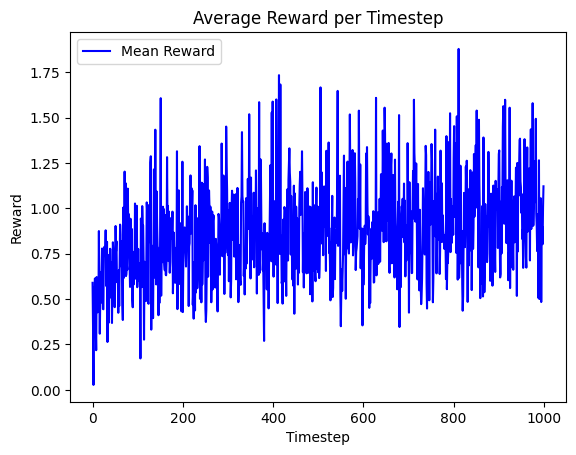

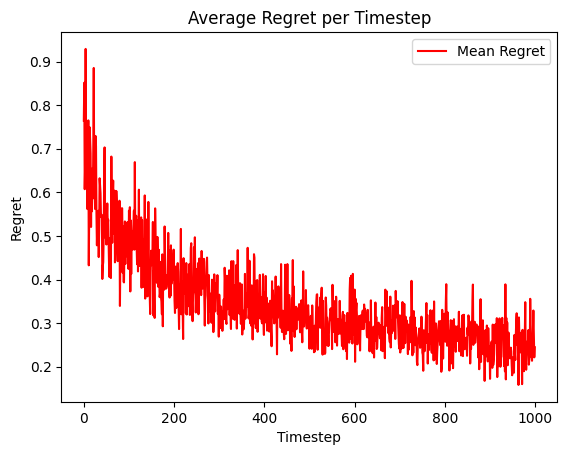

In [ ]:
# average reward per step
plt.figure()
plt.plot(rewards_mean, label='Mean Reward', color='blue', linewidth=1.5)
plt.title('Average Reward per Timestep')
plt.xlabel('Timestep')
plt.ylabel('Reward')
plt.legend()
plt.show()

# average regret per Step
plt.figure()
plt.plot(regrets_mean, label='Mean Regret', color='red', linewidth=1.5)
plt.title('Average Regret per Timestep')
plt.xlabel('Timestep')
plt.ylabel('Regret')
plt.legend()
plt.show()

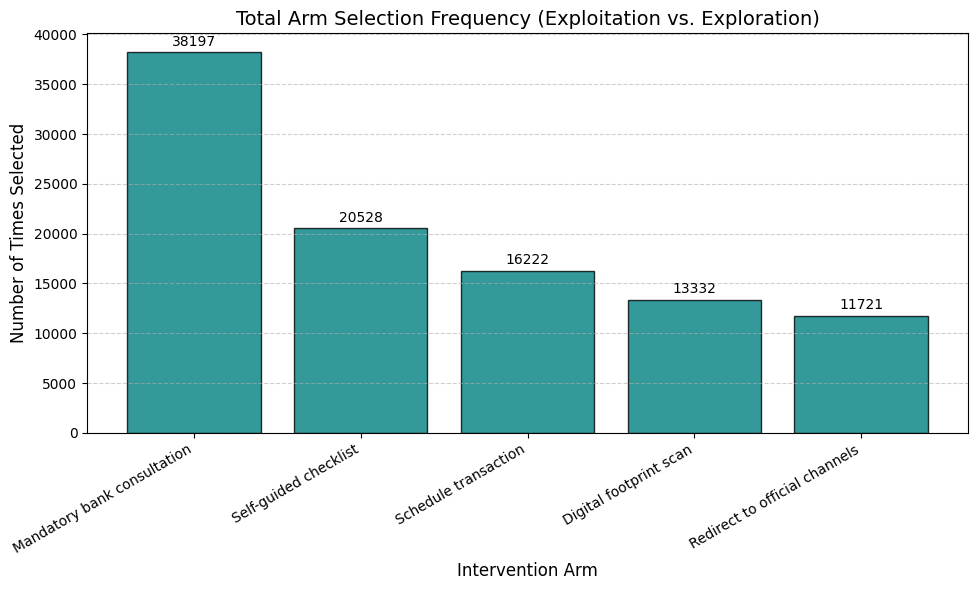

In [ ]:
arm_names = [arm.name for arm in ARMS]
counts = all_arm_counts

# sort the data by frequency (Highest to Lowest)
sorted_indices = np.argsort(counts)[::-1]
sorted_names = [arm_names[i] for i in sorted_indices]
sorted_counts = [counts[i] for i in sorted_indices]

# create the plot
plt.figure(figsize=(10, 6))
bars = plt.bar(sorted_names, sorted_counts, color='teal', alpha=0.8, edgecolor='black')
plt.title('Total Arm Selection Frequency (Exploitation vs. Exploration)', fontsize=14)
plt.ylabel('Number of Times Selected', fontsize=12)
plt.xlabel('Intervention Arm', fontsize=12)

plt.xticks(rotation=30, ha='right')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + (max(counts)*0.01), int(yval), ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()